# Session 1: Signals and Systems

The first notebook aims to get you familiar with concepts we'll talk about **a lot** in
future lectures. Look through them in class and ideally also afterwards to recap; change
inputs to see what the result is going to be, see if what you expect is what you get, 
and overall just make sure you understood the concepts properly, both in theory and in
their implications.

The core ideas to get familiar with here are:
- What is a **discrete-time** signal?
- What is a **system**?
- What makes a system **linear** and **time-invariant**?
- Why is the impulse response important?

I'll try to alternate between explanations, visualizations, and small tasks you can try
by yourself.

In [54]:
import numpy as np
import matplotlib.pyplot as plt

## What's a **discrete-time** signal, what's a **continuous** signal?

A **discrete-time** signal is a sequence at discrete, specified time points:

$x[0], x[1], x[2], ...$

There is **no information in-between**, we really only know what is happening at those
points in time (we have no idea what is happening at $x[0.5]$, for example)!

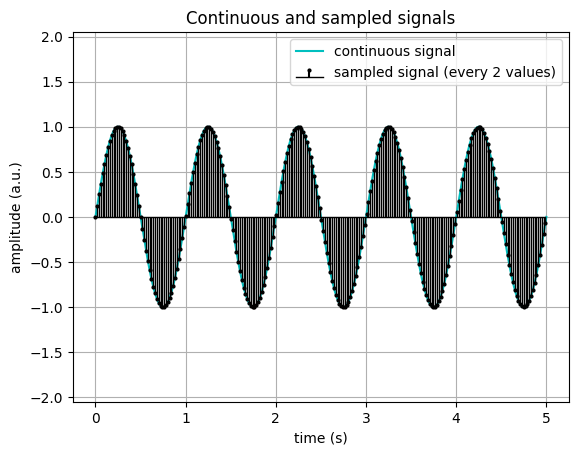

In [126]:
freq = 1                               # frequency in Hz
time = np.linspace(0, 5, 500)       # time vector from 0 to 5 seconds, with 500 samples
x_cont = np.sin(2*np.pi*freq*time)     # continuous-time signal (sine wave)
dn = 2                              # downsampling factor (keep every n-th sample)

plt.figure()

plt.plot(time, x_cont, 'c-', label='continuous signal')
markerline, stemlines, baseline = plt.stem(time[::dn], x_cont[::dn], 'k', label=f'sampled signal (every {dn} values)')
plt.setp(markerline, markersize=2)
plt.setp(stemlines, linewidth=1)
plt.setp(baseline, color='k', linewidth=1)
#plt.plot(time[::dn], x_cont[::dn], 'ko-', label=f'sampled signal (every {dn} values)')

plt.xlabel("time (s)")
plt.ylabel("amplitude (a.u.)")
plt.title("Continuous and sampled signals")
plt.legend()
plt.axis('equal')
plt.grid(True)

plt.show()

**In-class task**: 

- try out different values for `dn` and discuss
- where does discreteness come from in real-world data?

## What is a **system**?

A system is a **transformation**. It takes an input sequence ${x[n]}$ and produces an
output sequence ${y[n]}$. 

A simple example: the **moving average filter**.

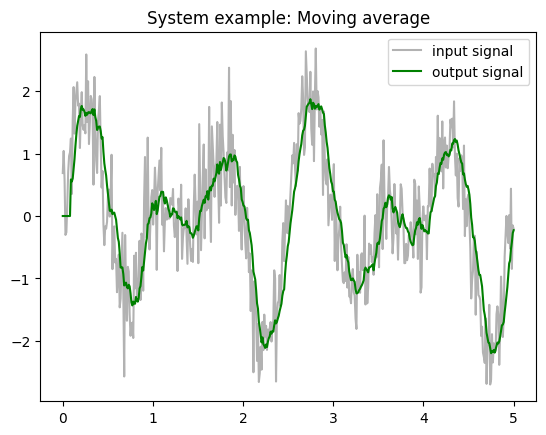

In [148]:
def moving_average(x, N=5):
    y = np.zeros(len(x))
    for n in range(len(x)):
        if n >= N-1:
            y[n] = np.mean(x[n-N+1:n+1])
    return y

signal = np.sin(2*np.pi*1.2*time) + np.sin(2*np.pi*0.8*time) + 0.5*np.random.randn(len(time))
y = moving_average(signal, N=10)

plt.plot(time, signal, 'k', alpha=0.3, label="input signal")
plt.plot(time, y, 'g', label="output signal")
plt.legend()
plt.title("System example: Moving average")
plt.show()

**In-class task**: 

- change `N` in the moving average filter; what happens?
- how does the system change the input?

## System properties

We discussed two important system properties: **linearity** and **time-invariance**.

**Linearity** means adding outputs or processing added inputs gives the same result. In math:

$H(a x_1 + b x_2) = a H(x_1) + b H(x_2)$

Let's check this for two arbitrary input sequences $x_1[n]$ and $x_2[n]$.


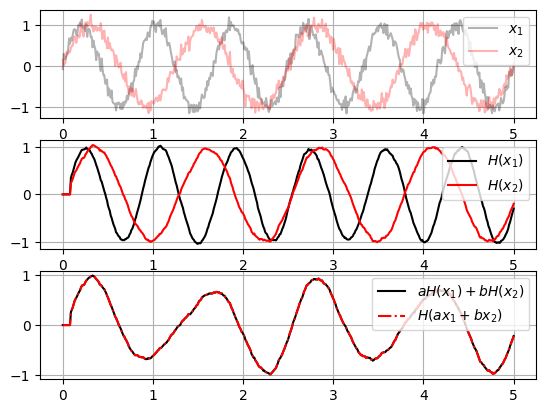

In [182]:
signal1 = np.sin(2*np.pi*1.2*time) + 0.1*np.random.randn(len(time))
signal2 = np.sin(2*np.pi*0.8*time) + 0.1*np.random.randn(len(time))
y1 = moving_average(signal1, N=10)
y2 = moving_average(signal2, N=10)
a, b = 0.2, 0.8

plt.figure()
plt.subplot(3,1,1)
plt.plot(time, signal1, 'k', alpha=0.3, label="$x_1$")
plt.plot(time, signal2, 'r', alpha=0.3, label="$x_2$")
plt.legend(loc='upper right')
plt.grid(True)
plt.subplot(3,1,2)
plt.plot(time, y1, 'k', label="$H(x_1)$")
plt.plot(time, y2, 'r', label="$H(x_2)$")
plt.legend(loc='upper right')
plt.grid(True)
plt.subplot(3,1,3)
plt.plot(time, a*y1+b*y2, 'k', label="$aH(x_1)+bH(x_2)$")
plt.plot(time, moving_average(a*signal1+b*signal2, N=10), 'r-.', label="$H(ax_1+bx_2)$")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()

As we just saw, the **moving average system** is **linear**.

What about time-invariance: If we shift the input, is the output shifted the same way?

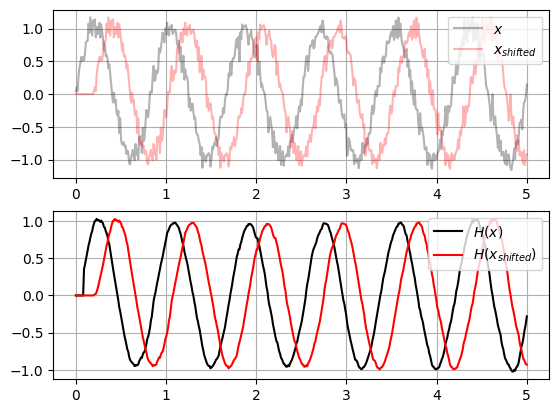

In [186]:
def shift(x, k):
    y = np.zeros_like(x)
    y[k:] = x[:-k]
    return y

k_shift = 20
signal1 = np.sin(2*np.pi*1.2*time) + 0.1*np.random.randn(len(time))
signal1_shifted = shift(signal1, k=k_shift)
y1 = moving_average(signal1, N=10)
y1_shifted = moving_average(signal1_shifted, N=10)

plt.figure()
plt.subplot(2,1,1)
plt.plot(time, signal1, 'k', alpha=0.3, label="$x$")
plt.plot(time, signal1_shifted, 'r', alpha=0.3, label="$x_{shifted}$")
plt.legend(loc='upper right')
plt.grid(True)
plt.subplot(2,1,2)
plt.plot(time, y1, 'k', label="$H(x)$")
plt.plot(time, y1_shifted, 'r', label="$H(x_{shifted})$")
plt.legend(loc='upper right')
plt.grid(True)
plt.show()


We only check it quantitatively here, but we see: if we shift the input by a certain number
of samples, the output is shiften by that number of samples as well - the moving average
system is **time-invariant**.

**In-class task:**
- think of a system that is **not** time-invariant and implement it quickly
- where do you see differences to the moving average system?

## Impulses and impulse response

We now calculated the moving average output for different input signals, but we didn't
gain any knowledge on the system **itself** - what is its general response, disregarding
the specific input signal? What does the moving average system **do**?

For that, we look at the system's **impulse response**, i.e., at how the system reacts
to the **Delta-Function**:

$\delta[n] = 1$ at $n=0$, \
$\delta[n] = 0$ otherwise

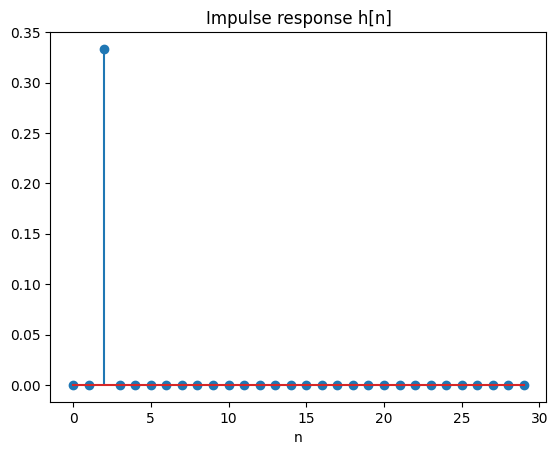

In [189]:
delta = np.zeros(100)
delta[0] = 1

h = moving_average(delta, N=3)

plt.stem(h[:30])
plt.title("Impulse response h[n]")
plt.xlabel("n")
plt.show()